# Model Evaluation

Evaluate fitted spike models: convergence diagnostics, sparsity analysis,
replicate parameter correlations, global epistasis plots, and mutation
parameter export.

**Outline**
1. Load fitted models and training data
2. Convergence diagnostics
3. Shift sparsity analysis
4. Replicate parameter correlations
5. Global epistasis plots
6. Export mutations DataFrame and intermediate CSVs

In [ ]:
import warnings

warnings.filterwarnings("ignore")

import os
import pickle
import sys

sys.path.insert(0, "notebooks")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import multidms.plot
from multidms.model_collection import ModelCollection

from _common import load_config, combine_replicate_muts

In [4]:
config_path = "config/config.yaml"

In [5]:
# Parameters
config_path = "../config/config.yaml"


In [4]:
config = load_config(config_path)
spike = config["spike"]
fit_config = spike["fitting"]
lasso_choice = spike["lasso_choice"]
condition_titles = spike["condition_titles"]
condition_colors = spike["condition_colors"]
experiment_conditions = spike["experiment_conditions"]

output_dir = spike.get("output_dir", "results")

## Load data

In [5]:
with open(os.path.join(output_dir, "fit_collection.pkl"), "rb") as f:
    fit_collection_df = pickle.load(f)

func_score_df = pd.read_csv(
    os.path.join(output_dir, "training_functional_scores.csv")
).fillna({"aa_substitutions": ""})

model_collection = ModelCollection(fit_collection_df)
print(f"Loaded {len(fit_collection_df)} fitted models")
print(f"Loaded {len(func_score_df):,} training variants")

Loaded 14 fitted models
Loaded 281,158 training variants


## Convergence diagnostics

In [6]:
# Build summary table with fitted alpha and beta0 parameters
summary_rows = []
for _, row in model_collection.fit_models.iterrows():
    jm = row.model._jax_model
    r = {
        "dataset": row.dataset_name,
        "fusionreg": row.fusionreg,
        "converged": row.converged,
        "fit_time": row.fit_time,
    }
    # Per-condition loss
    for cond in experiment_conditions:
        loss_col = f"{cond}_loss_training"
        if loss_col in model_collection.fit_models.columns:
            r[f"loss_{condition_titles.get(cond, cond)}"] = row[loss_col]
    # Fitted alpha and beta0 per condition
    for cond in experiment_conditions:
        title = condition_titles.get(cond, cond)
        r[f"alpha_{title}"] = float(jm.α[cond])
        r[f"beta0_{title}"] = float(jm.φ[cond].β0)
    summary_rows.append(r)

summary_df = pd.DataFrame(summary_rows)
print(f"{summary_df['converged'].sum()}/{len(summary_df)} models converged\n")
summary_df.round(3)

0/14 models converged



,dataset,fusionreg,converged,fit_time,loss_Delta,loss_BA.1,loss_BA.2,alpha_Delta,beta0_Delta,alpha_BA.1,beta0_BA.1,alpha_BA.2,beta0_BA.2
0,rep_1,0.0,False,9953,3145.543,9454.936,8267.671,5.797,0.276,5.726,0.362,5.744,0.116
1,rep_1,0.4,False,9146,3361.789,9457.529,8567.986,6.339,-0.009,5.786,0.335,6.308,-0.113
2,rep_1,0.8,False,10189,3889.278,9458.160,9039.229,5.951,0.088,5.790,0.334,6.526,-0.183
3,rep_1,1.6,False,9177,5516.588,9449.300,10227.039,2.414,0.727,5.624,0.405,5.502,0.177
4,rep_1,3.2,False,10226,6372.786,9444.375,11853.630,2.062,0.474,5.540,0.441,4.334,0.707
5,rep_1,6.4,False,10500,6602.874,9441.567,13398.171,1.967,0.571,5.493,0.461,4.004,0.671
6,rep_1,12.8,False,10700,6629.446,9439.947,14474.980,1.949,0.859,5.463,0.476,3.924,0.517
7,rep_2,0.0,False,10181,3598.456,7045.594,6728.011,5.945,0.118,5.781,0.381,5.234,0.381
8,rep_2,0.4,False,9844,3892.601,7048.817,7067.504,6.390,-0.060,5.836,0.357,5.857,0.061
9,rep_2,0.8,False,9713,4473.519,7048.696,7487.991,6.173,0.008,5.833,0.358,6.029,-0.013


In [7]:
conv_data = model_collection.convergence_trajectory_df(
    id_vars=("dataset_name", "fusionreg")
)
multidms.plot.convergence_trajectory(
    conv_data,
    id_cols=["dataset_name", "fusionreg"],
    title="Convergence trajectories",
)

alt.Chart(...)

## Shift sparsity

Fraction of shift parameters that are exactly zero, across the
regularization grid. Uses the `ModelCollection.shift_sparsity` method
which returns an interactive Altair chart faceted by dataset and
shift parameter.

In [8]:
sparsity_chart, sparsity_data = model_collection.shift_sparsity(return_data=True)
sparsity_chart

cache miss - this could take a moment


alt.FacetChart(...)

## Replicate parameter correlations

Correlation of mutation parameters (beta, shift) between replicates
across the regularization grid. Uses the `ModelCollection.mut_param_dataset_correlation`
method which returns an interactive Altair chart.

In [9]:
corr_chart, corr_data = model_collection.mut_param_dataset_correlation(
    return_data=True
)
corr_chart

alt.FacetChart(...)

## Global epistasis plots

Global epistasis (GE) landscape at the chosen lasso strength, showing
the fitted sigmoid mapping from latent to observed phenotype.

rep_1 (fusionreg=3.2):


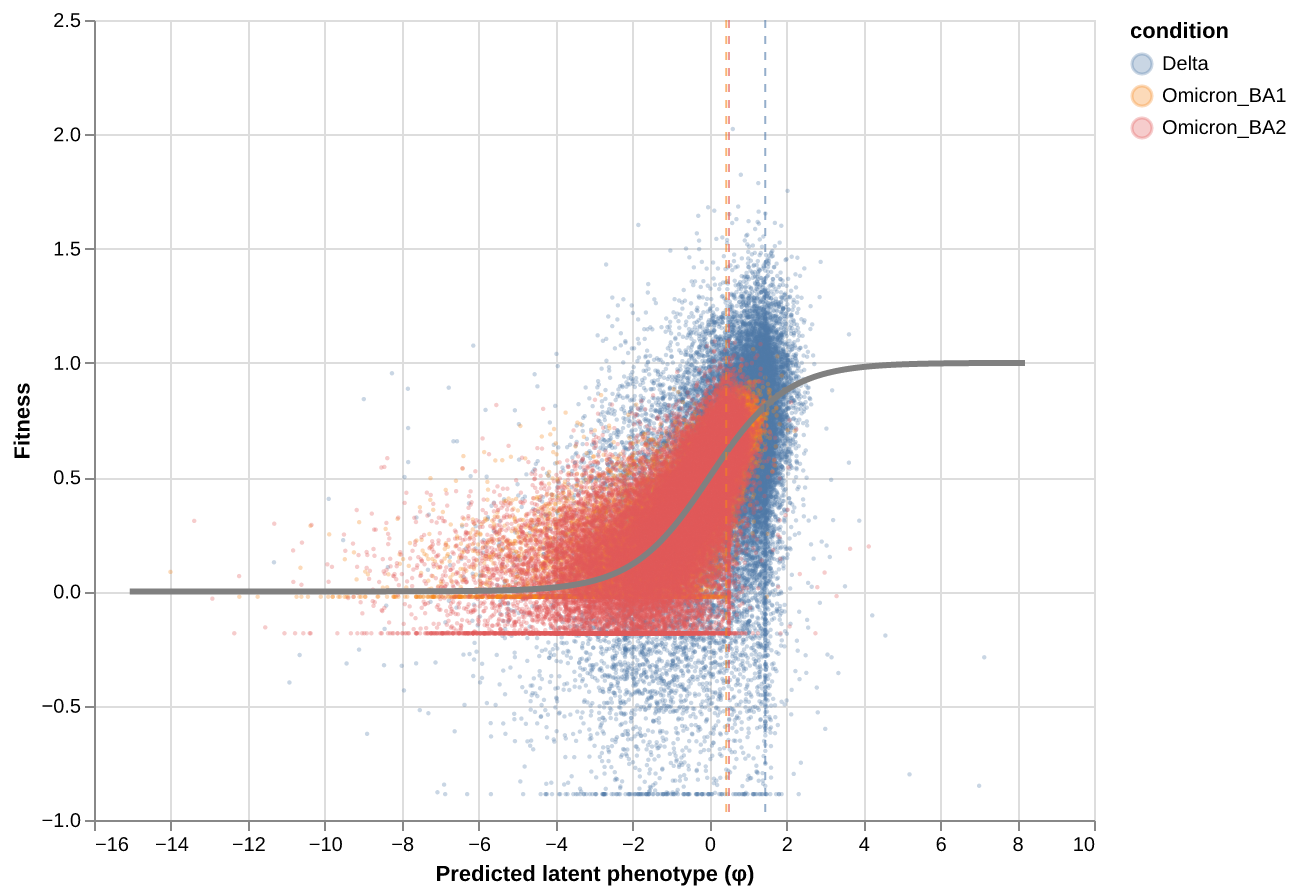

rep_2 (fusionreg=3.2):


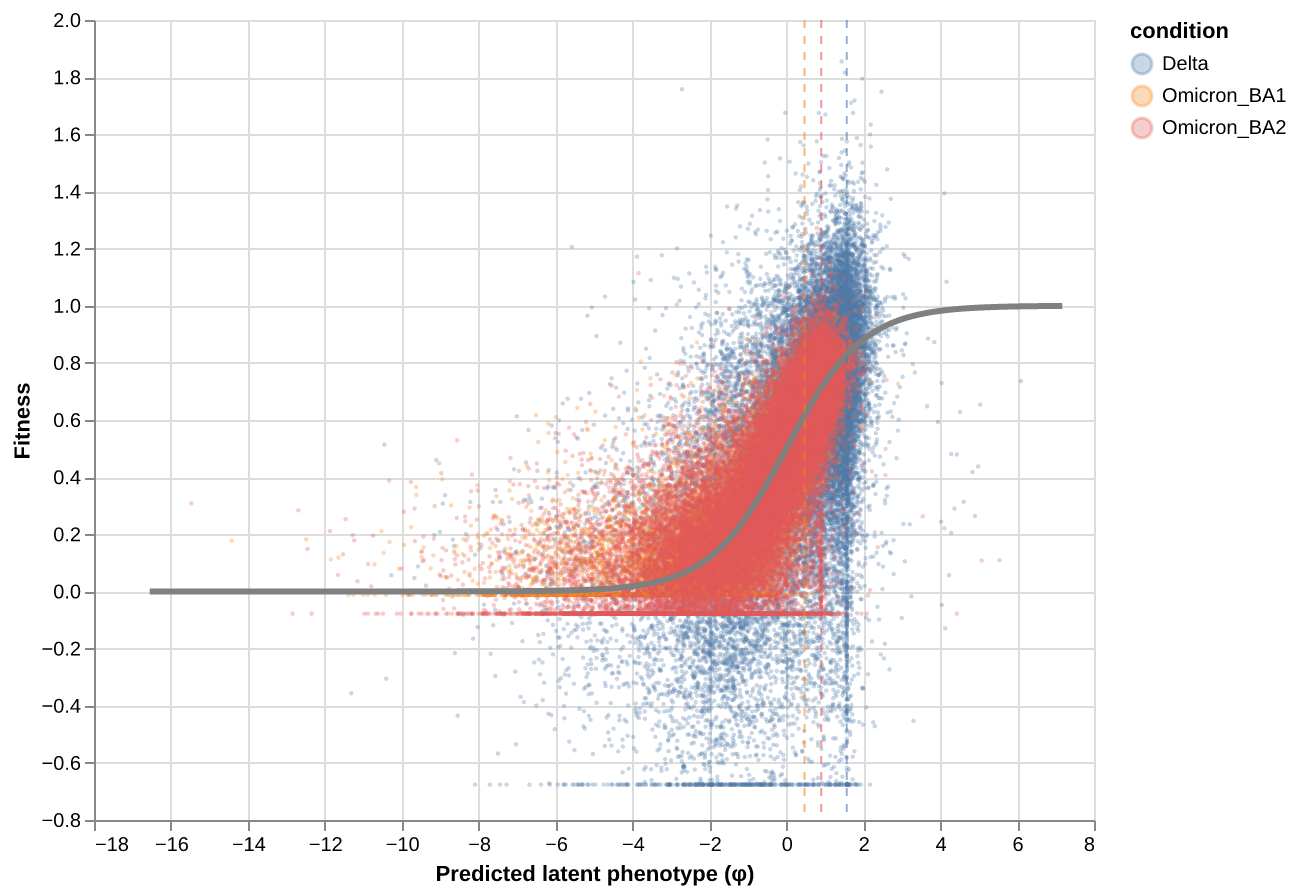

In [10]:
from IPython.display import display, Image
import tempfile

for ds_name in fit_collection_df["dataset_name"].unique():
    representative = (
        model_collection.fit_models
        .query(f"fusionreg == {lasso_choice} and dataset_name == '{ds_name}'")
    )
    if len(representative) == 0:
        print(f"No model at lasso={lasso_choice} for {ds_name}")
        continue
    model = representative.iloc[0].model
    print(f"{ds_name} (fusionreg={lasso_choice}):")
    chart = model.plot_ge_landscape()
    with tempfile.NamedTemporaryFile(suffix=".png") as tmp:
        chart.save(tmp.name, format="png", scale_factor=2)
        display(Image(filename=tmp.name))

## Export mutations DataFrame

Merge mutation parameters from both replicates at the chosen lasso strength.

In [11]:
fit_dict = {}
for _, row in model_collection.fit_models.query(
    f"fusionreg == {lasso_choice}"
).iterrows():
    fit_dict[row.dataset_name] = row.model

mutations_df = combine_replicate_muts(fit_dict)

mutations_df["sense"] = np.where(
    mutations_df["muts"].str.contains("*", regex=False),
    "stop",
    "nonsynonymous",
)

print(f"mutations_df: {len(mutations_df):,} mutations")
print(f"  nonsynonymous: {(mutations_df['sense'] == 'nonsynonymous').sum():,}")
print(f"  stop: {(mutations_df['sense'] == 'stop').sum():,}")
mutations_df.head()

mutations_df: 9,398 mutations
  nonsynonymous: 9,188
  stop: 210


,mutation,wts,sites,muts,rep_1_beta_Delta,rep_2_beta_Delta,avg_beta_Delta,rep_1_beta_Omicron_BA1,rep_2_beta_Omicron_BA1,avg_beta_Omicron_BA1,rep_1_beta_Omicron_BA2,rep_2_beta_Omicron_BA2,avg_beta_Omicron_BA2,rep_1_shift_Delta,rep_2_shift_Delta,avg_shift_Delta,rep_1_shift_Omicron_BA2,rep_2_shift_Omicron_BA2,avg_shift_Omicron_BA2,sense
0,M1F,M,1,F,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,nonsynonymous
1,M1I,M,1,I,-2.712322,-2.085437,-2.398879,-2.712322,-2.085437,-2.398879,-2.712322,-2.509083,-2.610702,0.0,0.0,0.0,0.0,-0.423645,-0.211823,nonsynonymous
2,M1K,M,1,K,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,nonsynonymous
3,M1L,M,1,L,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,nonsynonymous
4,M1T,M,1,T,-2.111557,-2.214748,-2.163153,-2.111557,-2.214748,-2.163153,-2.111557,-2.214748,-2.163153,0.0,0.0,0.0,0.0,0.000000,0.000000,nonsynonymous


## Save outputs

In [12]:
groupby = ("dataset_name", "fusionreg")
collection_muts_df = model_collection.split_apply_combine_muts(
    groupby=groupby
)

mutations_df.to_csv(os.path.join(output_dir, "mutations_df.csv"), index=False)
print(f"Saved mutations_df.csv ({len(mutations_df):,} rows)")

collection_muts_df.to_csv(os.path.join(output_dir, "collection_muts.csv"), index=False)
print(f"Saved collection_muts.csv ({len(collection_muts_df):,} rows)")

sparsity_data.to_csv(os.path.join(output_dir, "fit_sparsity.csv"), index=False)
print(f"Saved fit_sparsity.csv ({len(sparsity_data)} rows)")

corr_data.to_csv(os.path.join(output_dir, "library_replicate_correlation.csv"), index=False)
print(f"Saved library_replicate_correlation.csv ({len(corr_data)} rows)")

Saved mutations_df.csv (9,398 rows)


Saved collection_muts.csv (131,572 rows)
Saved fit_sparsity.csv (56 rows)
Saved library_replicate_correlation.csv (56 rows)
